# Gaussian Process Regression using Scikit-Learn for NOx Emissions Prediction

This notebook presents an implementation of **Gaussian Process Regression (GPR) using Scikit-Learn** to predict Nitrogen Oxides (NOx) emissions of gas turbines. We train GP models using standard kernels (including ARD) and compare their performance against baseline models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel


## 2. Dataset Ingestion and Preprocessing


In [2]:
df = pd.read_csv('gt_2014.csv')
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().dropna()
print("Cleaned Shape:", df.shape)


Dataset Shape: (7158, 11)
Missing Values: 0
Duplicates: 7
Cleaned Shape: (7151, 11)


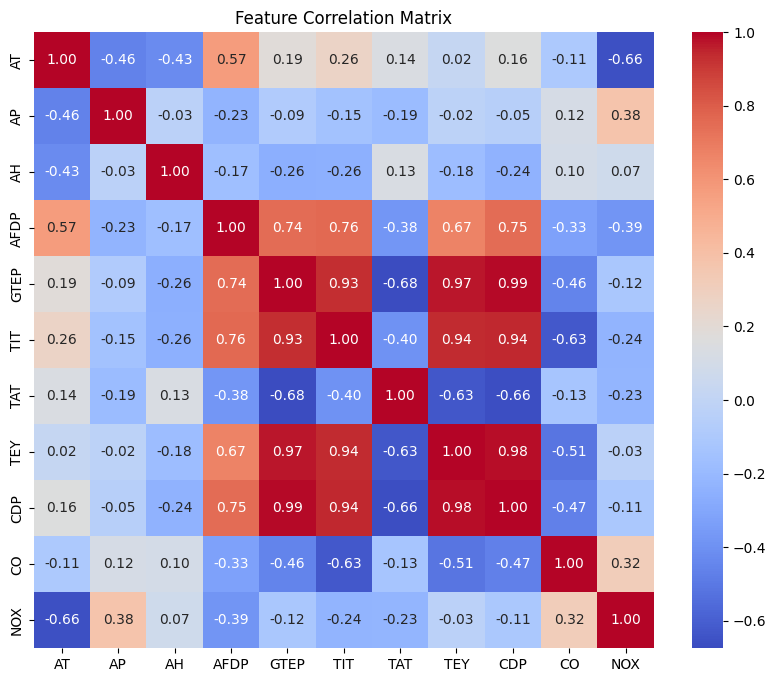

In [3]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()


In [4]:
X = df.drop(columns=['NOX']).values
Y = df['NOX'].values
print("Features shape:", X.shape)
print("Target shape:", Y.shape)


Features shape: (7151, 10)
Target shape: (7151,)


### 2.3 Train-Test Split & Feature Z-score Standardization

Since we predict emissions from concurrent sensor readings (not temporal lags), this is a static regression task. We shuffle and split the data randomly (80/20) and standardize features using training statistics.


In [5]:
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

X_train_raw = X[indices[:split]]
X_test_raw = X[indices[split:]]
Y_train_orig = Y[indices[:split]]
Y_test_orig = Y[indices[split:]]

# Scale using training parameters
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0) + 1e-8
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

Y_mean = np.mean(Y_train_orig)
Y_std = np.std(Y_train_orig) + 1e-8
Y_train_norm = (Y_train_orig - Y_mean) / Y_std
Y_test_norm = (Y_test_orig - Y_mean) / Y_std

print(f"Training features: {X_train.shape}, Test features: {X_test.shape}")


Training features: (5720, 10), Test features: (1431, 10)


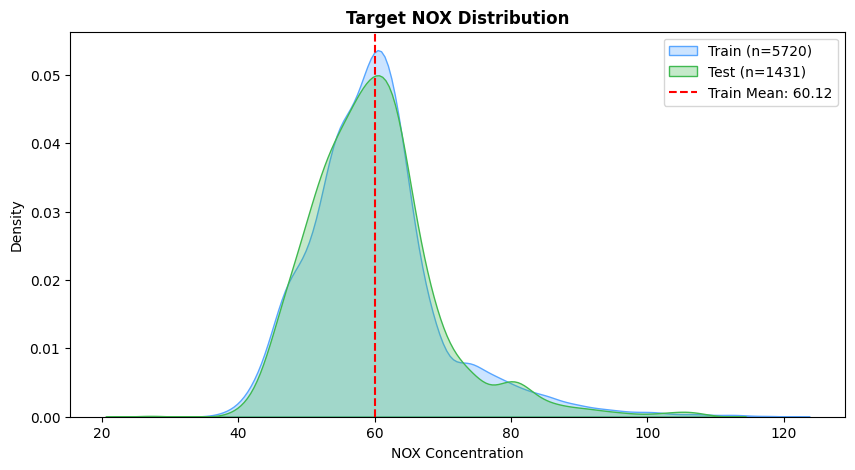

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(Y_train_orig, fill=True, alpha=0.3, color='#58a6ff', label=f'Train (n={len(Y_train_orig)})')
sns.kdeplot(Y_test_orig, fill=True, alpha=0.3, color='#3fb950', label=f'Test (n={len(Y_test_orig)})')
plt.axvline(np.mean(Y_train_orig), color='red', linestyle='--', label=f'Train Mean: {np.mean(Y_train_orig):.2f}')
plt.title("Target NOX Distribution", fontweight='bold')
plt.xlabel("NOX Concentration")
plt.ylabel("Density")
plt.legend()
plt.show()


### 2.4 Calculating Noise Variance dynamically from Dataset

We fit a multiple linear regression model to the standardized training data and estimate the noise variance as the variance of the training residuals.


In [7]:
X_tr_b = np.hstack([np.ones((len(X_train), 1)), X_train])
w_noise = np.linalg.solve(X_tr_b.T @ X_tr_b + 1e-8 * np.eye(X_tr_b.shape[1]), X_tr_b.T @ Y_train_norm)
noise = np.var(Y_train_norm - X_tr_b @ w_noise)
print("Estimated Noise Variance (sigma_n^2):", noise)


Estimated Noise Variance (sigma_n^2): 0.4282257736978814


## 3. GPR Implementation with RBF Kernel


In [8]:
kernel = ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed")


In [9]:
gpr = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=True, random_state=42)
gpr.fit(X_train, Y_train_orig)
print("Learned Kernel (Fixed):", gpr.kernel_)


Learned Kernel (Fixed): 1**2 * RBF(length_scale=1)


In [10]:
posterior_mean, posterior_std = gpr.predict(X_test, return_std=True)
lower = posterior_mean - 1.96 * posterior_std
upper = posterior_mean + 1.96 * posterior_std


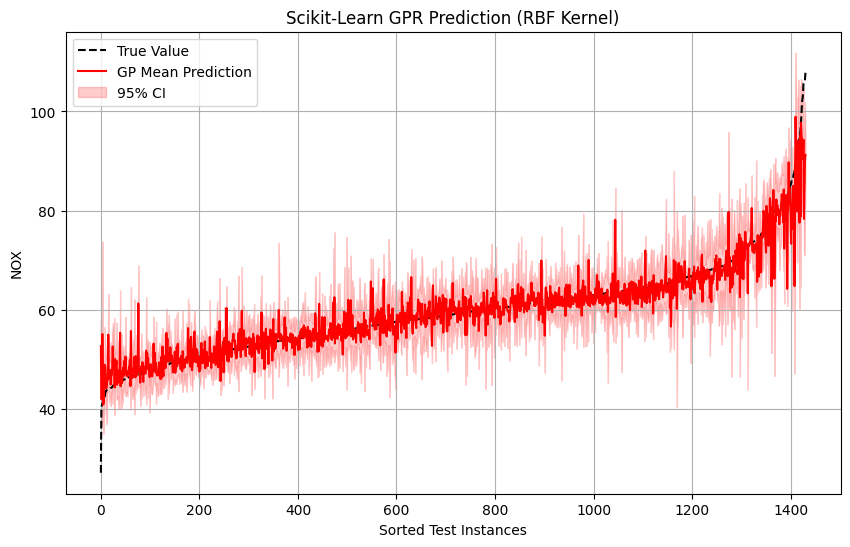

In [11]:
sort_idx = np.argsort(Y_test_orig)
Y_test_sorted = Y_test_orig[sort_idx]
x_axis = np.arange(len(Y_test_sorted))

plt.figure(figsize=(10,6))
plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=1.5)
plt.plot(x_axis, posterior_mean[sort_idx], 'r-', label='GP Mean Prediction', linewidth=1.5)
plt.fill_between(x_axis, lower[sort_idx], upper[sort_idx], color='red', alpha=0.2, label='95% CI')
plt.xlabel("Sorted Test Instances")
plt.ylabel("NOX")
plt.title("Scikit-Learn GPR Prediction (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


### 3.4 Quantifying Prediction Performance (RMSE, MAE, R², NLL)


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(Y_test_orig, posterior_mean))
mae = mean_absolute_error(Y_test_orig, posterior_mean)
r2 = r2_score(Y_test_orig, posterior_mean)

from scipy.stats import norm
nll = -np.mean(norm.logpdf(Y_test_orig, loc=posterior_mean, scale=posterior_std))

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)
print("NLL =", nll)


RMSE = 3.0945079438344867
MAE = 1.9015850516019492
R2 = 0.8948109143119354
NLL = 2.475490823019414


## 5. Comparison of Covariance Functions (GPML Chapter 4)

We set up a dictionary of four GPR kernels in Scikit-Learn.


In [13]:
ls_ard = np.array([1.44280934e+00, 3.03775851e+00, 5.44148096e+00, 1.07544436e+00, 
                   1.45084583e+00, 2.03155204e+03, 2.61453978e+00, 1.46254579e+00, 
                   1.45201245e+04, 7.71528905e-01])

kernels = {
    "RBF": ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed"),
    "Matern": ConstantKernel(1.0, "fixed") * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5),
    "RQ": ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.0, length_scale_bounds="fixed", alpha=1.0, alpha_bounds="fixed"),
    "ARD": ConstantKernel(1.0, "fixed") * RBF(length_scale=ls_ard, length_scale_bounds="fixed")
}


In [14]:
results = {}
for name, kernel in kernels.items():
    gpr_k = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=True, random_state=42)
    gpr_k.fit(X_train, Y_train_orig)
    mean, std = gpr_k.predict(X_test, return_std=True)
    results[name] = {
        "mean": mean,
        "variance": std ** 2
    }
    print(f"Scikit-Learn GP with {name} kernel trained.")


Scikit-Learn GP with RBF kernel trained.
Scikit-Learn GP with Matern kernel trained.
Scikit-Learn GP with RQ kernel trained.
Scikit-Learn GP with ARD kernel trained.


In [15]:
from scipy.stats import norm
comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    variance = results[name]["variance"]
    std = np.sqrt(variance)
    
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mae_val = mean_absolute_error(Y_test_orig, pred)
    r2_val = r2_score(Y_test_orig, pred)
    nll_val = -np.mean(norm.logpdf(Y_test_orig, loc=pred, scale=std))
    
    comparison.append([name, rmse_val, mae_val, r2_val, nll_val])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Kernel", "RMSE", "MAE", "R2", "NLL"]
)
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)


   Kernel      RMSE       MAE        R2       NLL
1  Matern  2.889904  1.749633  0.908261  2.436502
2      RQ  2.890578  1.792676  0.908218  2.344684
0     RBF  3.094508  1.901585  0.894811  2.475491
3     ARD  3.331866  2.093734  0.878055  5.029519


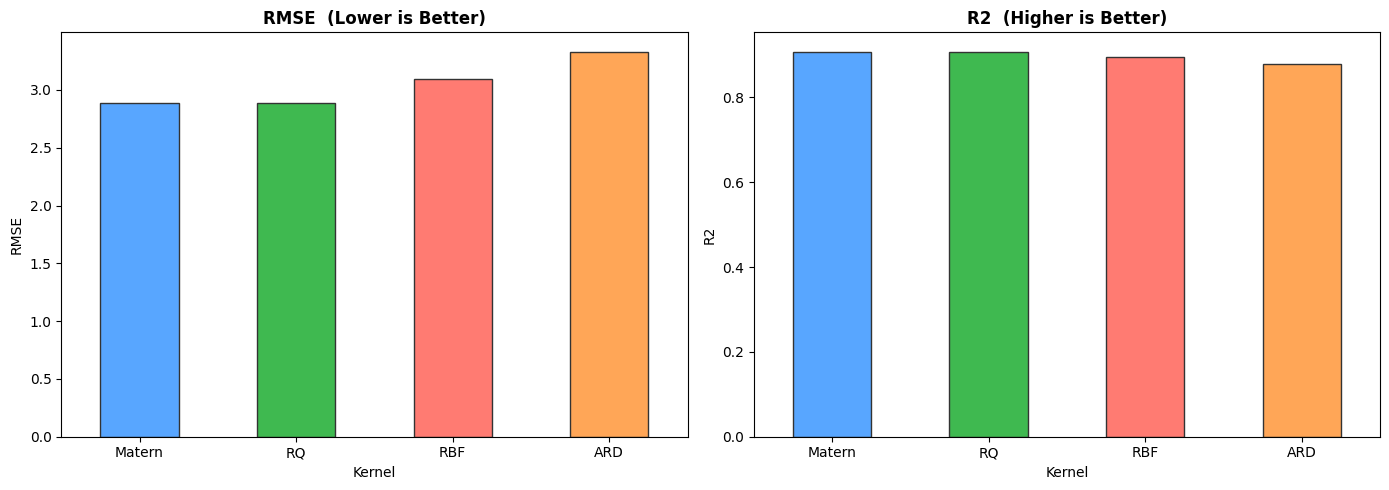

In [16]:
colors = ["#58a6ff", "#3fb950", "#ff7b72", "#ffa657"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot = comparison_df.set_index("Kernel")

df_plot["RMSE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="#333")
axes[0].set_title("RMSE  (Lower is Better)", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].set_xticklabels(df_plot.index, rotation=0)

df_plot["R2"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="#333")
axes[1].set_title("R2  (Higher is Better)", fontweight="bold")
axes[1].set_ylabel("R2")
axes[1].set_xticklabels(df_plot.index, rotation=0)
plt.tight_layout()
plt.show()


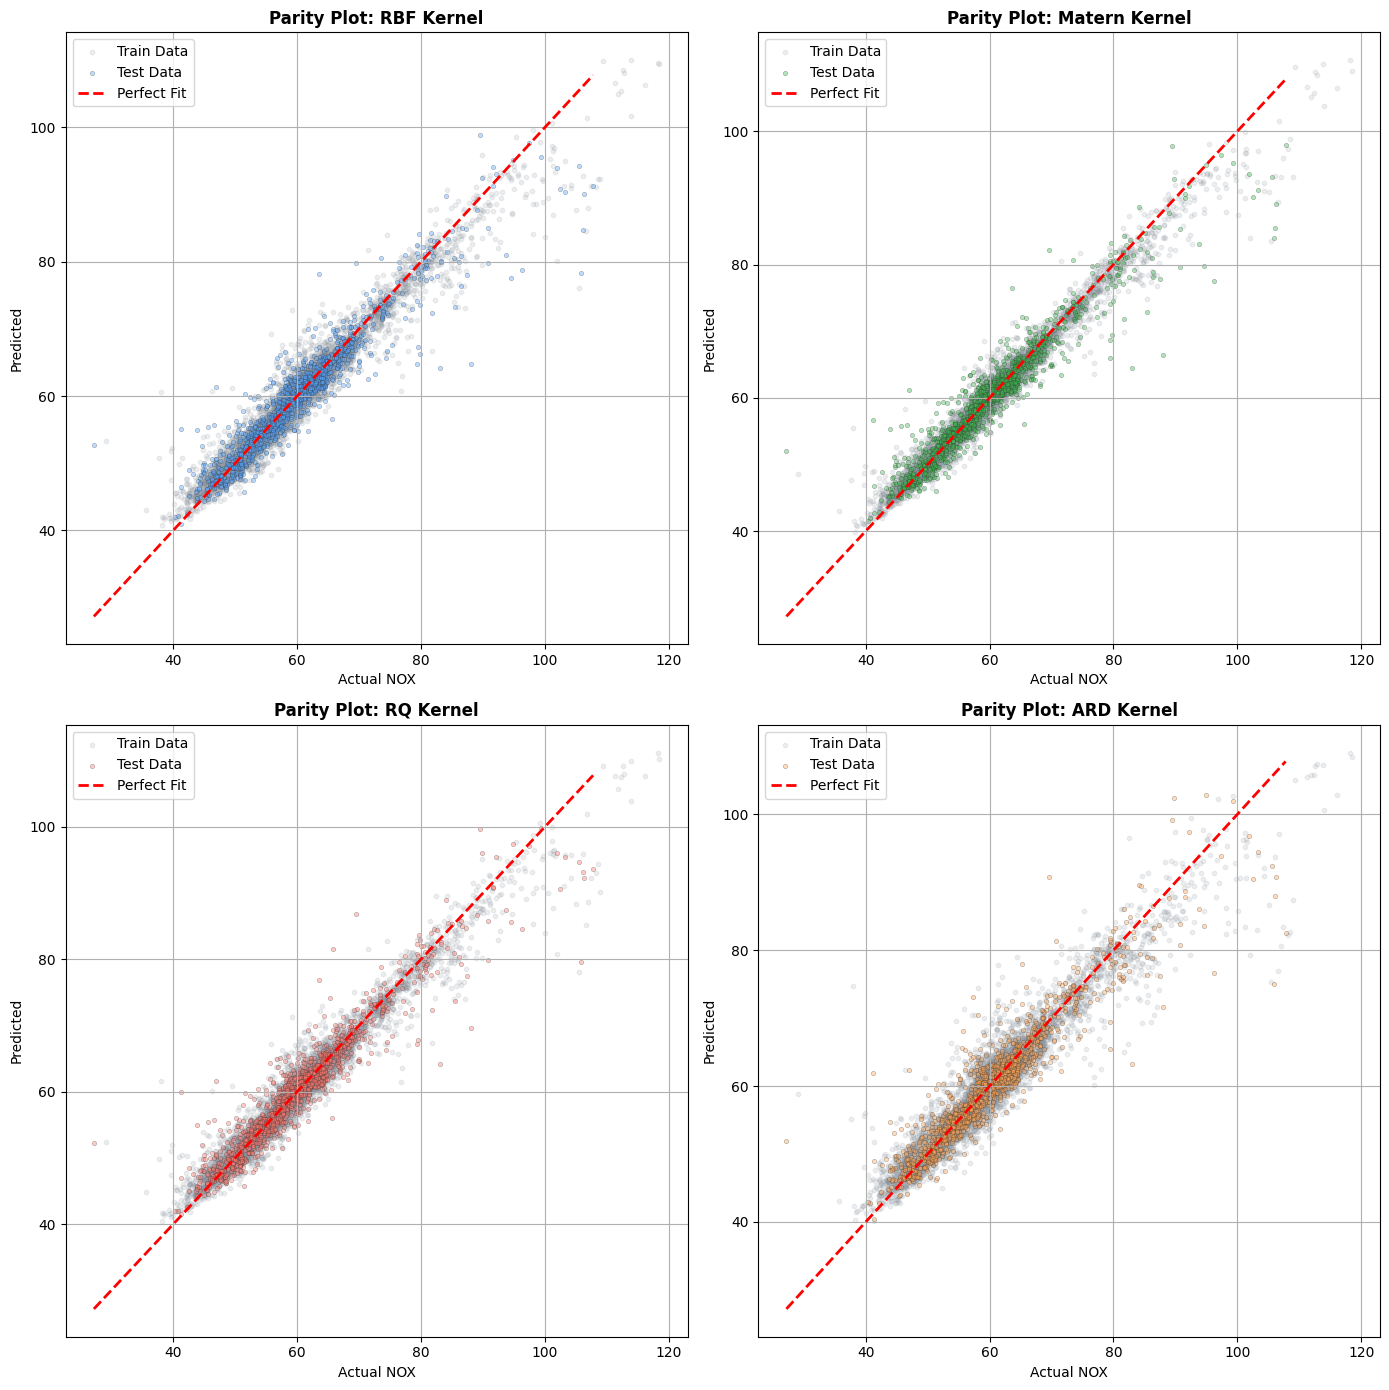

In [17]:
# Train predictions for parity plot
train_predictions = {}
fitted_models = {}
for name, kernel in kernels.items():
    gpr_k = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=True, random_state=42)
    gpr_k.fit(X_train, Y_train_orig)
    train_predictions[name] = gpr_k.predict(X_train)
    fitted_models[name] = gpr_k

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()
for i, name in enumerate(results.keys()):
    ax = axes[i]
    pred_te = results[name]["mean"]
    pred_tr = train_predictions[name]
    ax.scatter(Y_train_orig, pred_tr, color="#8b949e", alpha=0.15, s=10, label="Train Data")
    ax.scatter(Y_test_orig,  pred_te, color=colors[i], alpha=0.4,  s=10,
               edgecolors="#333", linewidths=0.4, label="Test Data")
    lo = min(Y_test_orig.min(), pred_te.min())
    hi = max(Y_test_orig.max(), pred_te.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label="Perfect Fit")
    ax.set_title(f"Parity Plot: {name} Kernel", fontweight="bold")
    ax.set_xlabel("Actual NOX"); ax.set_ylabel("Predicted")
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()


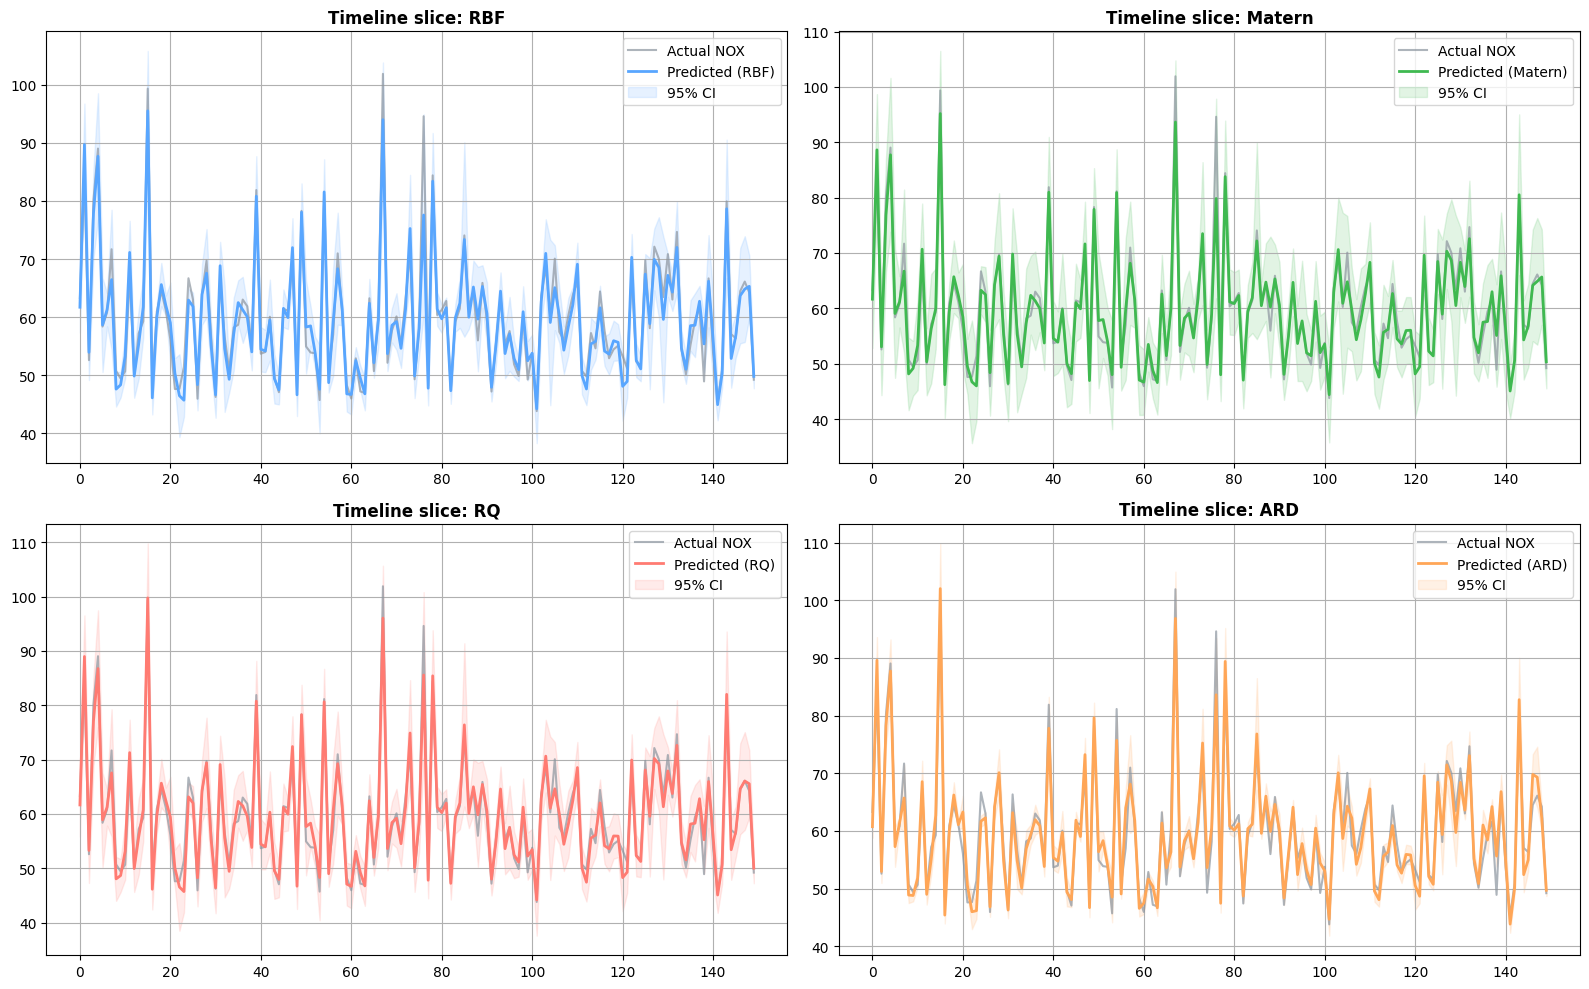

In [18]:
slice_idx = 150
t = np.arange(slice_idx)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, name in enumerate(results.keys()):
    ax = axes[i]
    pred = results[name]["mean"]
    std = np.sqrt(results[name]["variance"])
    ax.plot(t, Y_test_orig[:slice_idx], color="#8b949e", alpha=0.7,
            linewidth=1.5, label="Actual NOX")
    ax.plot(t, pred[:slice_idx], color=colors[i], linewidth=2,
            label=f"Predicted ({name})")
    ax.fill_between(t, pred[:slice_idx] - 1.96*std[:slice_idx], pred[:slice_idx] + 1.96*std[:slice_idx],
                    color=colors[i], alpha=0.15, label="95% CI")
    ax.set_title(f"Timeline slice: {name}", fontweight="bold")
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()


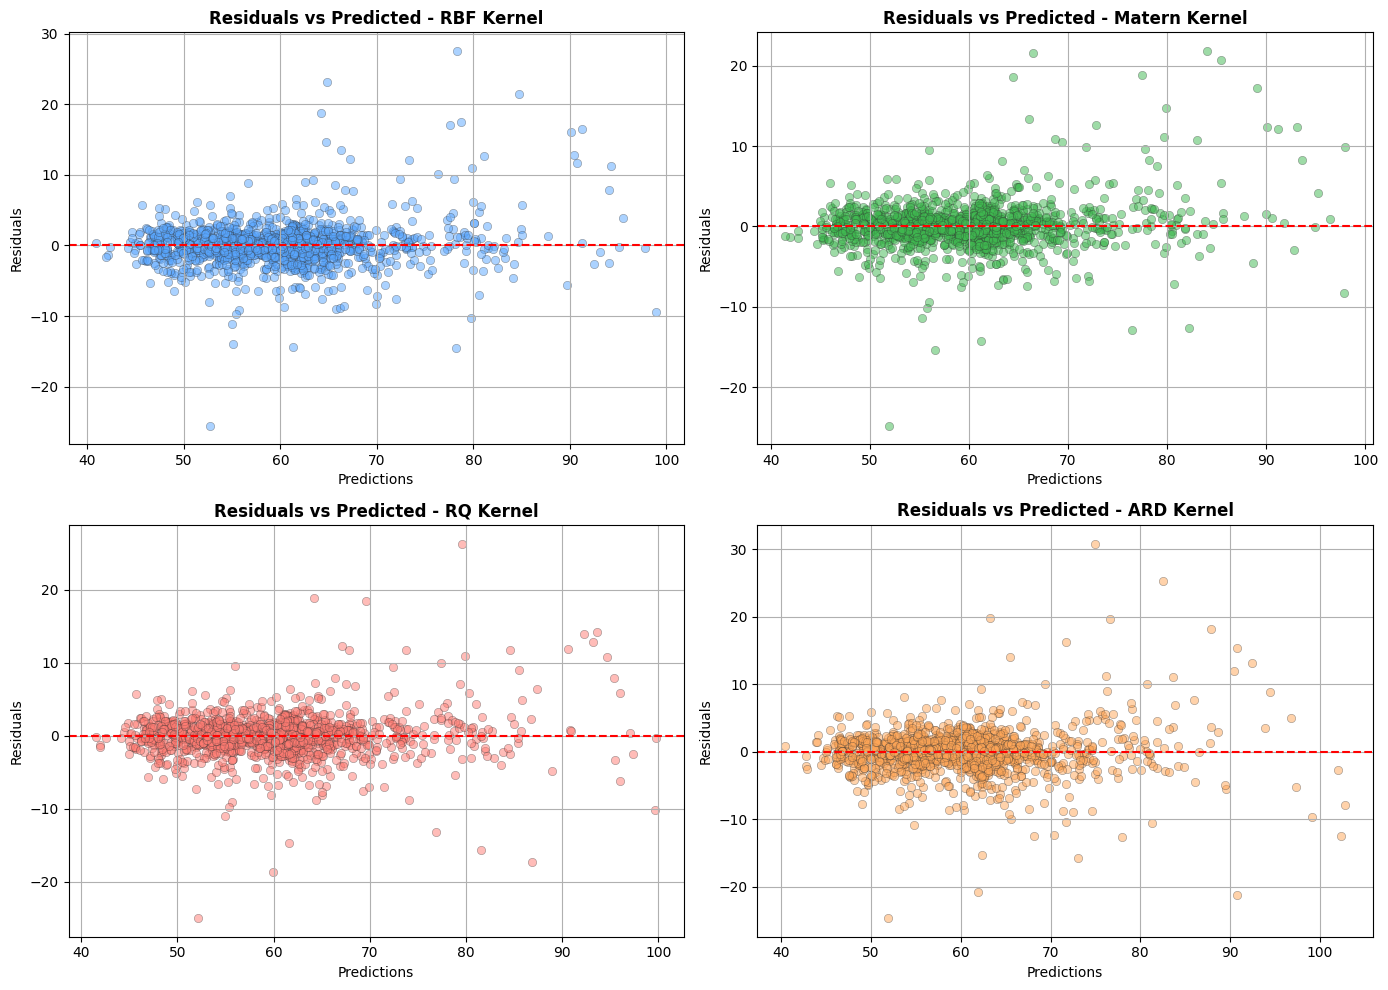

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, name in enumerate(results.keys()):
    ax  = axes[i]
    pred = results[name]["mean"]
    res = Y_test_orig - pred
    ax.scatter(pred, res, color=colors[i], alpha=0.5, edgecolors="#333", linewidths=0.4)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residuals vs Predicted - {name} Kernel", fontweight="bold", fontsize=12)
    ax.set_xlabel("Predictions"); ax.set_ylabel("Residuals"); ax.grid(True)
plt.tight_layout()
plt.show()


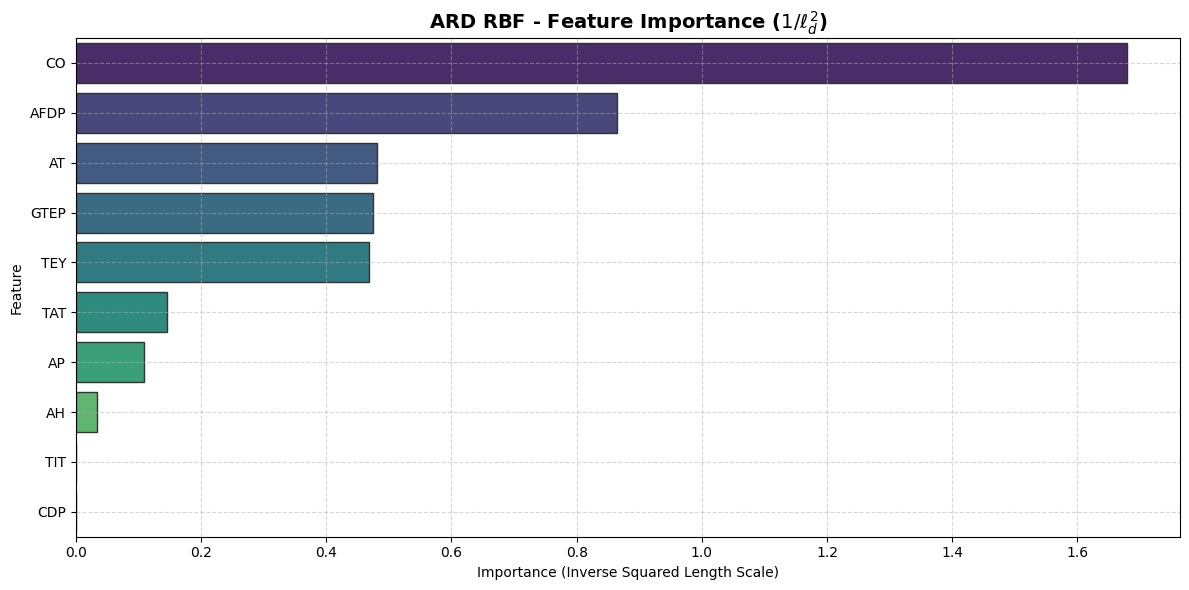

In [20]:
features = df.drop(columns=['NOX']).columns
importance = 1.0 / (ls_ard ** 2)
imp_df = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df,
            palette="viridis", hue="Feature", legend=False, edgecolor="#333")
plt.title("ARD RBF - Feature Importance ($1/\ell_d^2$)", fontweight="bold", fontsize=14)
plt.xlabel("Importance (Inverse Squared Length Scale)")
plt.ylabel("Feature")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
sample = pd.DataFrame({
    "Actual":    Y_test_orig[:20],
    "Predicted": results["Matern"]["mean"][:20],
    "Error":     np.abs(Y_test_orig[:20] - results["Matern"]["mean"][:20]),
})
print("Sample Predictions (First 20 Test Rows - Matern Kernel):")
print(sample.round(4).to_string(index=False))


Sample Predictions (First 20 Test Rows - Matern Kernel):
 Actual  Predicted  Error
 63.287    61.6584 1.6286
 84.073    88.6238 4.5508
 52.579    53.0472 0.4682
 80.237    76.8430 3.3940
 89.035    87.7306 1.3044
 58.366    59.0741 0.7081
 60.810    61.1907 0.3807
 71.684    66.7245 4.9595
 50.721    48.1556 2.5654
 49.407    49.1743 0.2327
 50.651    53.3031 2.6521
 67.376    70.6856 3.3096
 49.952    50.3535 0.4015
 57.207    56.3201 0.8869
 59.264    59.9627 0.6987
 99.368    95.1768 4.1912
 48.543    46.2155 2.3275
 60.954    59.4028 1.5512
 64.467    65.7111 1.2441
 61.129    62.3587 1.2297


In [22]:
x_new = X_test[0:1]
pred_sc, std_sc = fitted_models["Matern"].predict(x_new, return_std=True)

print("Single Point Prediction (First Test Row):")
print(f"  Prediction          : {pred_sc[0]:.4f}")
print(f"  Uncertainty (sigma) : {std_sc[0]:.4f}")
print(f"  Actual              : {Y_test_orig[0]:.4f}")


Single Point Prediction (First Test Row):
  Prediction          : 61.6584
  Uncertainty (sigma) : 4.4904
  Actual              : 63.2870


### 5.6 1-D GP Visualizations


In [23]:
corr_with_nox = df.corr(numeric_only=True)["NOX"].drop("NOX")
print("Correlations with NOX:")
print(corr_with_nox.sort_values(ascending=False))


Correlations with NOX:
AP      0.377725
CO      0.317575
AH      0.071595
TEY    -0.031907
CDP    -0.109777
GTEP   -0.117364
TAT    -0.227256
TIT    -0.236547
AFDP   -0.385069
AT     -0.656490
Name: NOX, dtype: float64


In [24]:
def gp_plot_1d(kernel_obj, title, X_gp, y_gp, X_grid, noise_val):
    gp = GaussianProcessRegressor(kernel=kernel_obj, alpha=noise_val, optimizer=None, normalize_y=True, random_state=42)
    gp.fit(X_gp, y_gp)
    mean, std = gp.predict(X_grid, return_std=True)
    
    plt.figure(figsize=(14, 7))
    plt.scatter(X_gp, y_gp, s=15, alpha=0.35, color="steelblue", label="Observed Data")
    plt.plot(X_grid, mean, color="red", linewidth=2, label="GP Mean Prediction")
    plt.fill_between(X_grid.flatten(), mean - 1.96*std, mean + 1.96*std, color="red", alpha=0.15, label="95% CI")
    plt.title(title, fontweight="bold", fontsize=14)
    plt.xlabel("Feature Value")
    plt.ylabel("NOX")
    plt.legend()
    plt.grid(True)
    plt.show()

X_gp = df[["AFDP"]].values
X_gp_mean = np.mean(X_gp)
X_gp_std = np.std(X_gp)
X_gp_norm = (X_gp - X_gp_mean) / X_gp_std
X_grid_raw = np.linspace(X_gp.min(), X_gp.max(), 200).reshape(-1, 1)
X_grid_norm = (X_grid_raw - X_gp_mean) / X_gp_std
y_gp = df["NOX"].values
Y_gp_mean = np.mean(y_gp)
Y_gp_std = np.std(y_gp)


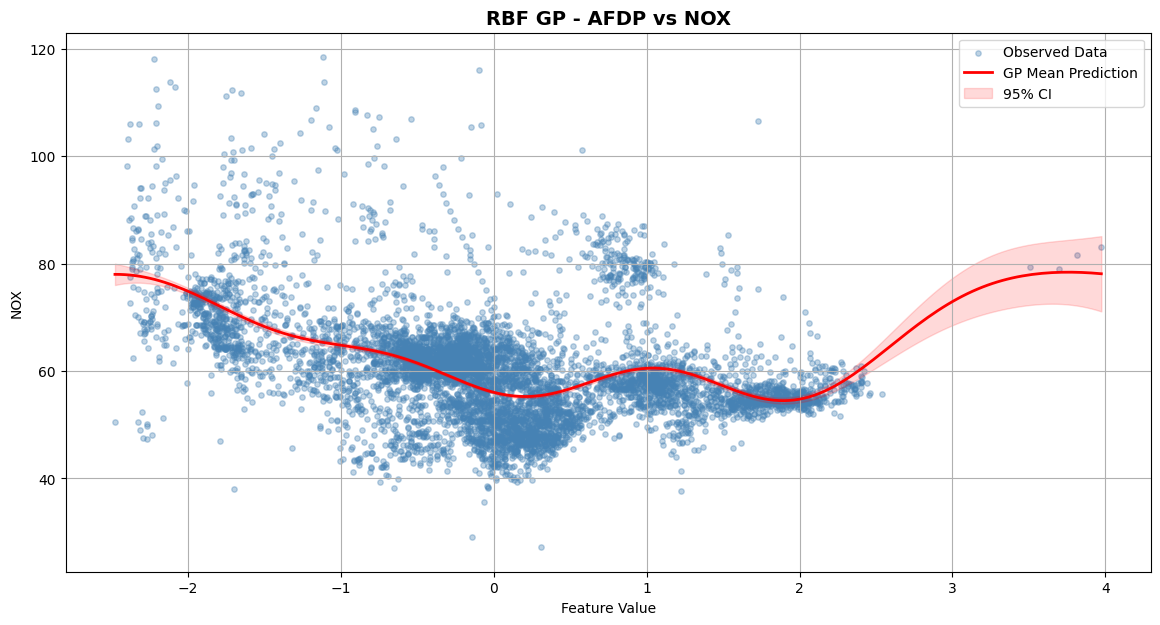

In [25]:
gp_plot_1d(ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed"), "RBF GP - AFDP vs NOX", X_gp_norm, y_gp, X_grid_norm, noise)


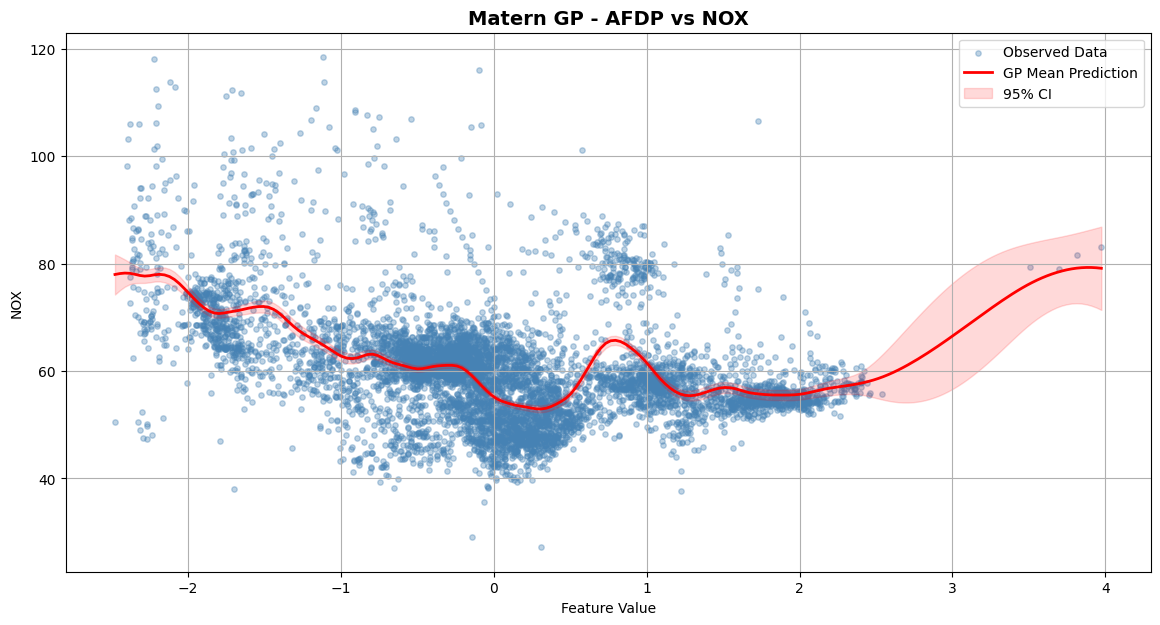

In [26]:
gp_plot_1d(ConstantKernel(1.0, "fixed") * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5), "Matern GP - AFDP vs NOX", X_gp_norm, y_gp, X_grid_norm, noise)


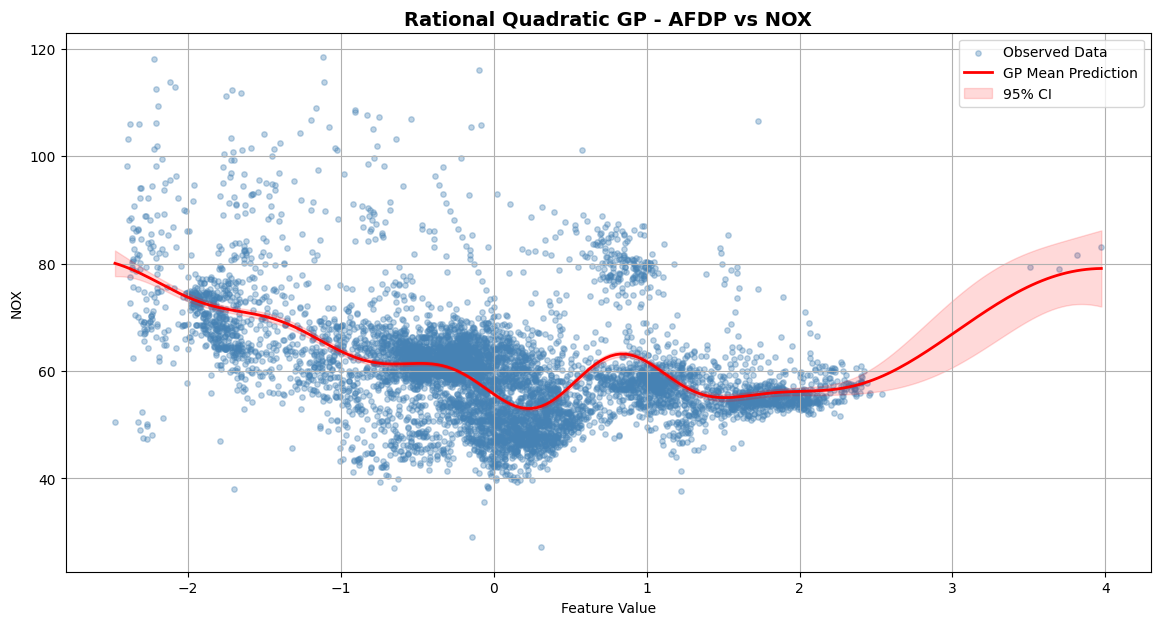

In [27]:
gp_plot_1d(ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.0, alpha=1.0, alpha_bounds="fixed", length_scale_bounds="fixed"), "Rational Quadratic GP - AFDP vs NOX", X_gp_norm, y_gp, X_grid_norm, noise)


In [28]:
X_gp2 = df[["AT"]].values
X_gp2_mean = np.mean(X_gp2)
X_gp2_std = np.std(X_gp2)
X_gp2_norm = (X_gp2 - X_gp2_mean) / X_gp2_std
X_grid_raw2 = np.linspace(X_gp2.min(), X_gp2.max(), 200).reshape(-1, 1)
X_grid_norm2 = (X_grid_raw2 - X_gp2_mean) / X_gp2_std
y_gp2 = df["NOX"].values
Y_gp2_mean = np.mean(y_gp2)
Y_gp2_std = np.std(y_gp2)


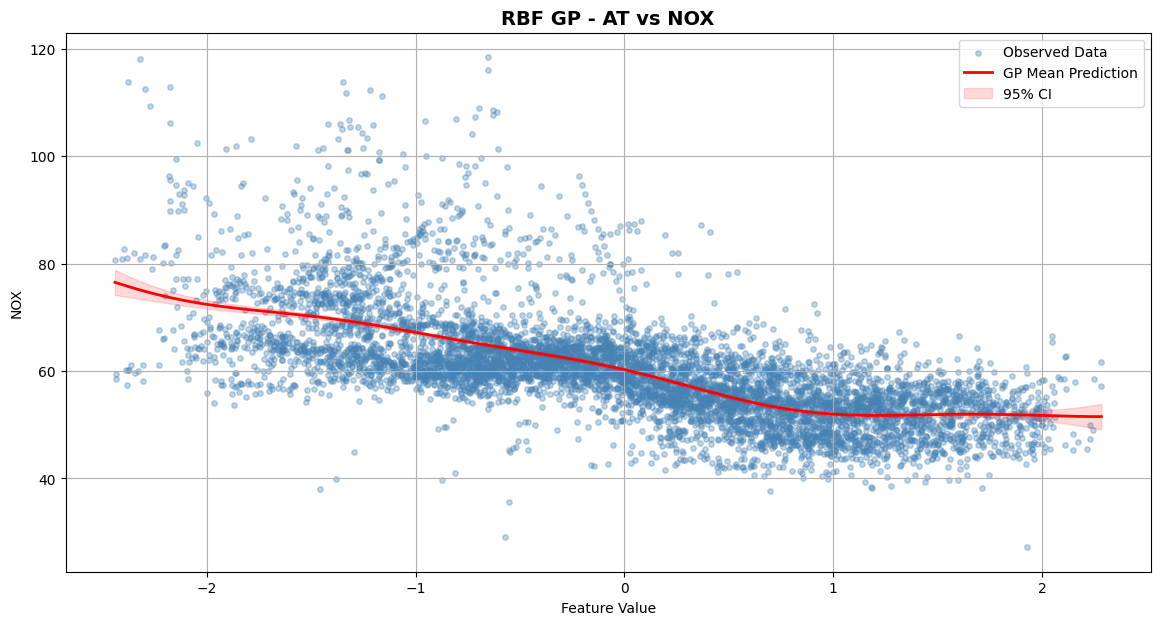

In [29]:
gp_plot_1d(ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed"), "RBF GP - AT vs NOX", X_gp2_norm, y_gp2, X_grid_norm2, noise)


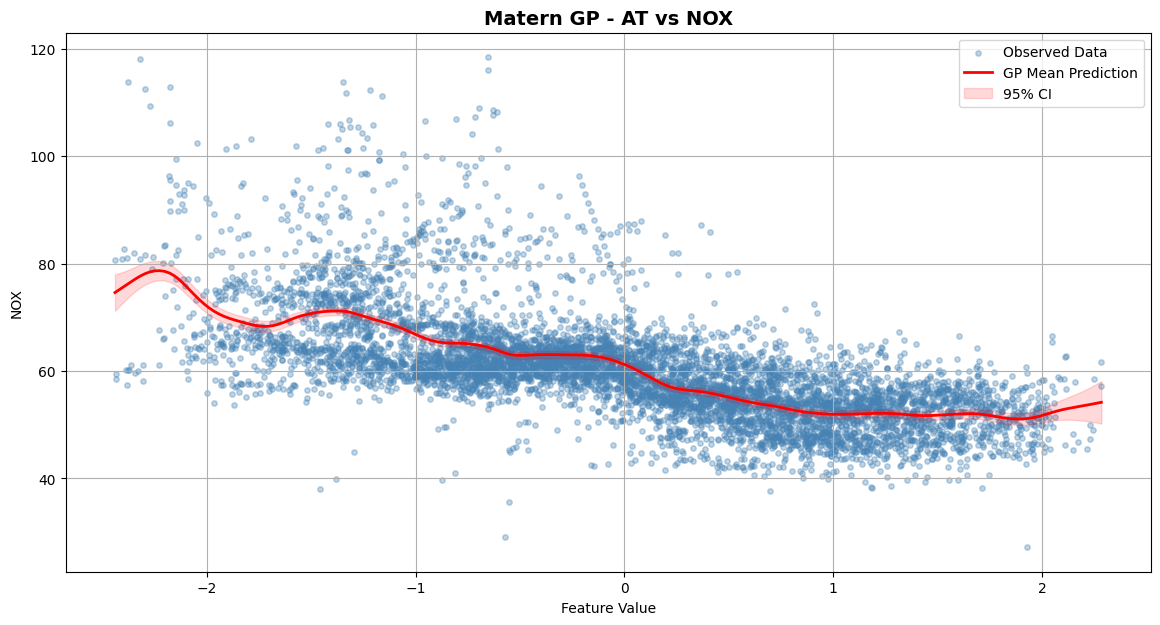

In [30]:
gp_plot_1d(ConstantKernel(1.0, "fixed") * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5), "Matern GP - AT vs NOX", X_gp2_norm, y_gp2, X_grid_norm2, noise)


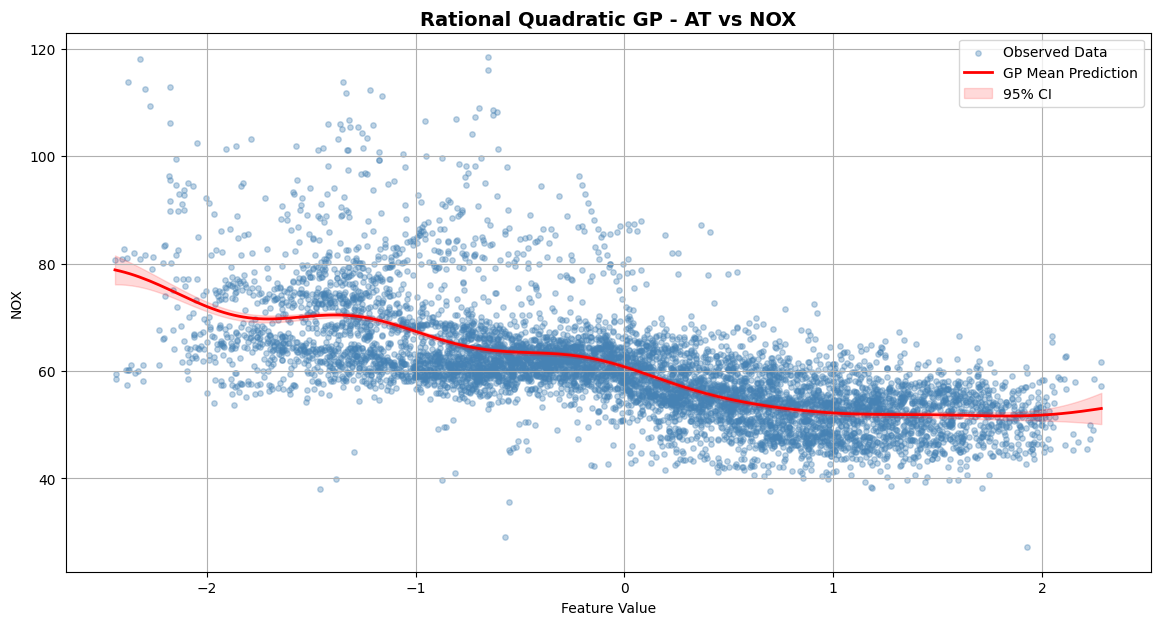

In [31]:
gp_plot_1d(ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.0, alpha=1.0, alpha_bounds="fixed", length_scale_bounds="fixed"), "Rational Quadratic GP - AT vs NOX", X_gp2_norm, y_gp2, X_grid_norm2, noise)


## 6. Comparison with Baseline Machine Learning Models

We implement baseline regressors (Linear Regression, Polynomial Regression, KNN, and Decision Tree) using standard Scikit-Learn implementations.


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

class PolynomialRegressionSklearn:
    def __init__(self, degree=2):
        self.degree = degree
        self.model = LinearRegression()
    def fit(self, X, y):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        self.model.fit(X_poly, y)
    def predict(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        return self.model.predict(X_poly)

models_baseline = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (Deg 2)": PolynomialRegressionSklearn(degree=2),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_train, Y_train_orig)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained successfully.")


Baseline 'Linear Regression' trained successfully.
Baseline 'Polynomial Regression (Deg 2)' trained successfully.
Baseline 'K-Nearest Neighbors' trained successfully.
Baseline 'Decision Tree' trained successfully.


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, y_pred))
    mae_val = mean_absolute_error(Y_test_orig, y_pred)
    r2_val = r2_score(Y_test_orig, y_pred)
    mape_val = mean_absolute_percentage_error(Y_test_orig, y_pred)
    baseline_results.append([name, rmse_val, mae_val, r2_val, mape_val])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)


                           Model      RMSE       MAE        R2      MAPE
2            K-Nearest Neighbors  3.241098  1.921925  0.884609  0.032129
3                  Decision Tree  5.357995  3.626576  0.684651  0.059488
1  Polynomial Regression (Deg 2)  5.747332  3.772462  0.637156  0.061135
0              Linear Regression  6.154854  4.183948  0.583876  0.068366


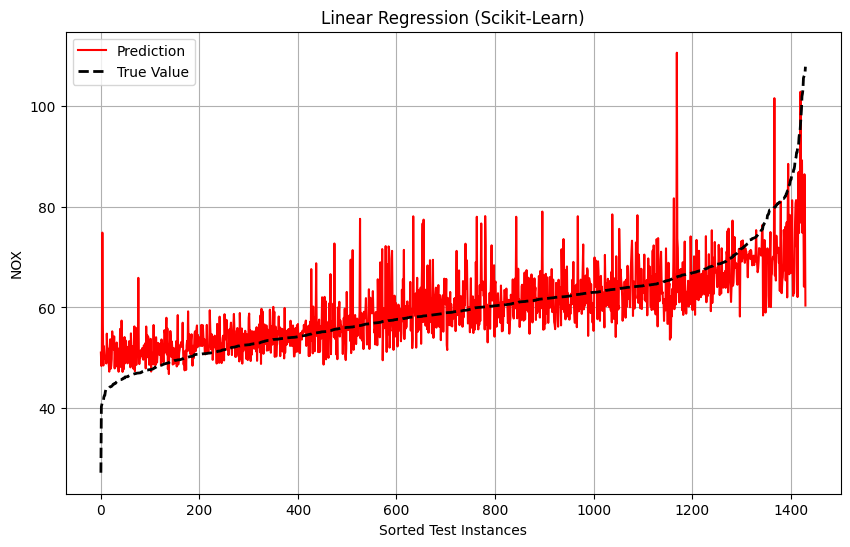

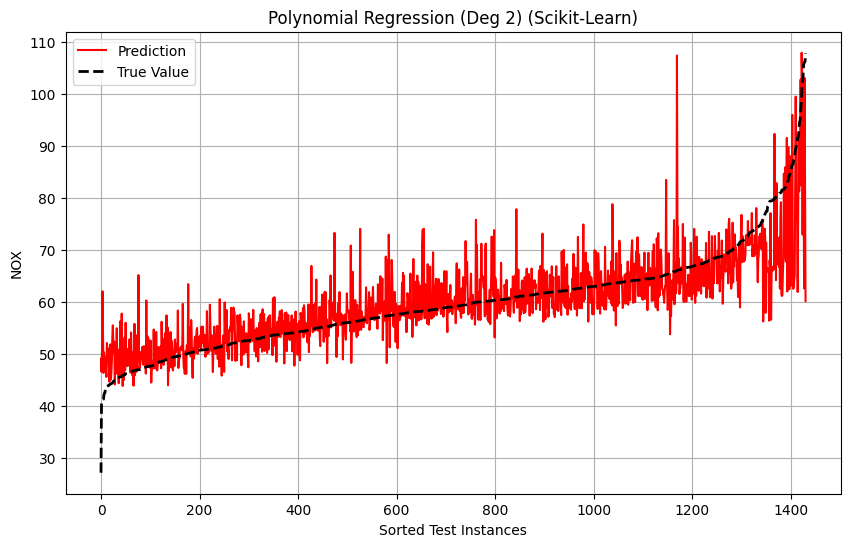

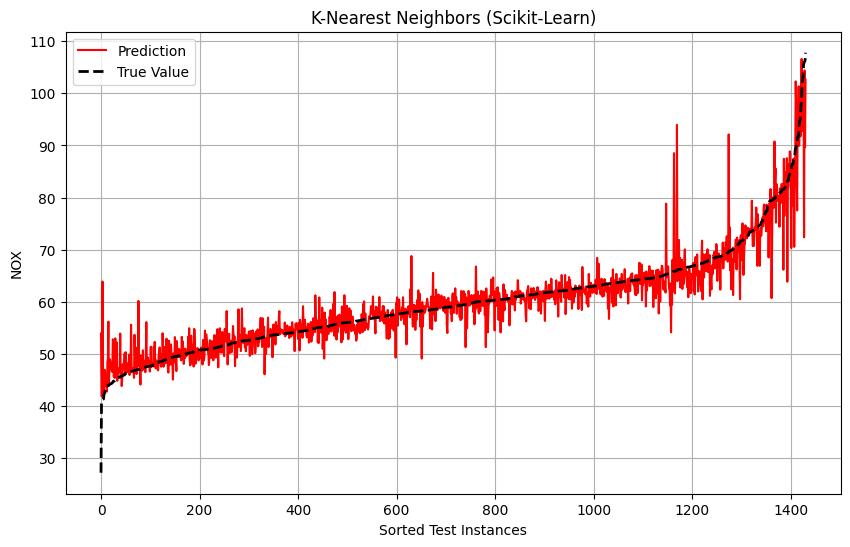

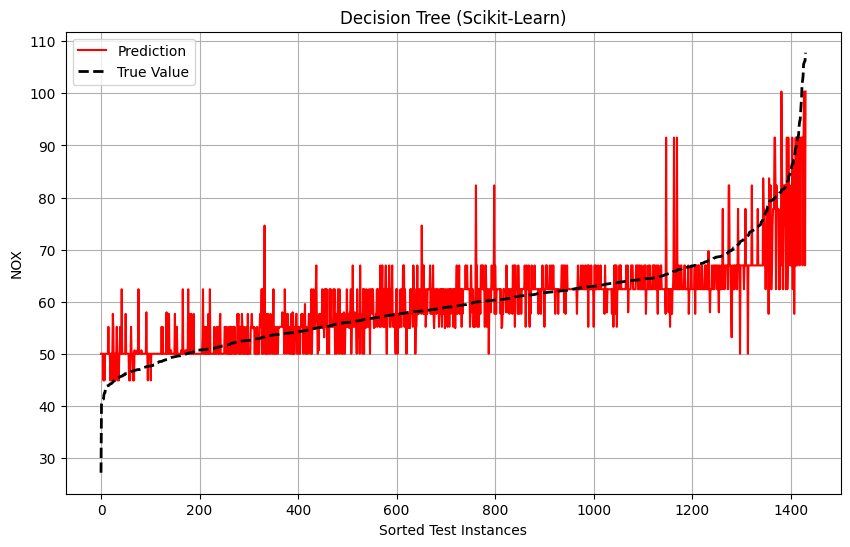

In [34]:
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(10,6))
    plt.plot(x_axis, y_pred[sort_idx], 'r-', label='Prediction', linewidth=1.5)
    plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
    plt.title(f"{name} (Scikit-Learn)")
    plt.xlabel("Sorted Test Instances")
    plt.ylabel("NOX")
    plt.legend()
    plt.grid(True)
    plt.show()


## 7. Summary and Model Ranking


In [35]:
joint_results = []
for name in results.keys():
    pred = results[name]["mean"]
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape_val = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape_val)
    joint_results.append([f"GPR ({name})", rmse_val, accuracy])
    
for name, model in trained_baselines.items():
    pred = model.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape_val = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape_val)
    joint_results.append([name, rmse_val, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)


                           Model      RMSE  Accuracy (%)
1                   GPR (Matern)  2.889904     97.093505
2                       GPR (RQ)  2.890578     96.996857
0                      GPR (RBF)  3.094508     96.844474
6            K-Nearest Neighbors  3.241098     96.787145
3                      GPR (ARD)  3.331866     96.524022
7                  Decision Tree  5.357995     94.051235
5  Polynomial Regression (Deg 2)  5.747332     93.886484
4              Linear Regression  6.154854     93.163429


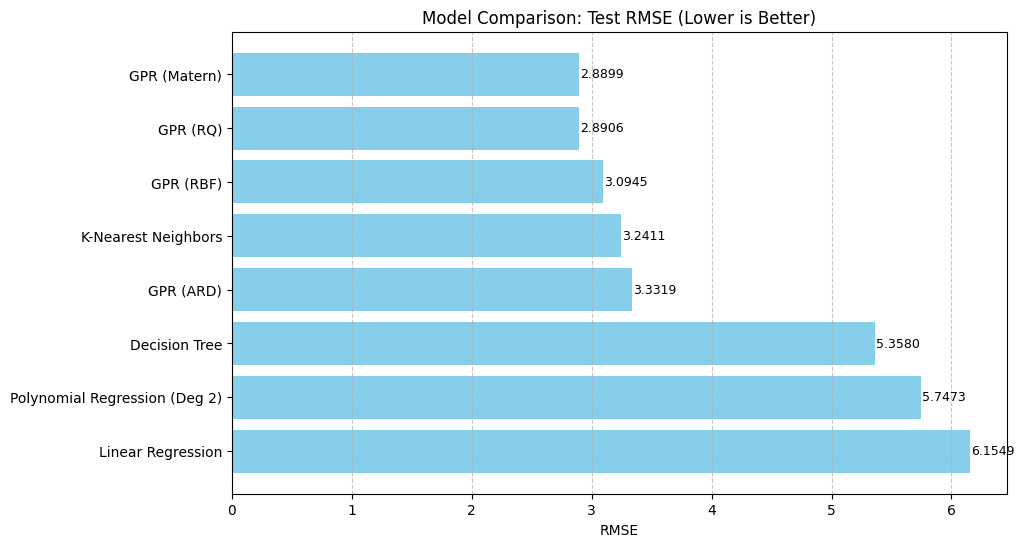

In [36]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.4f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


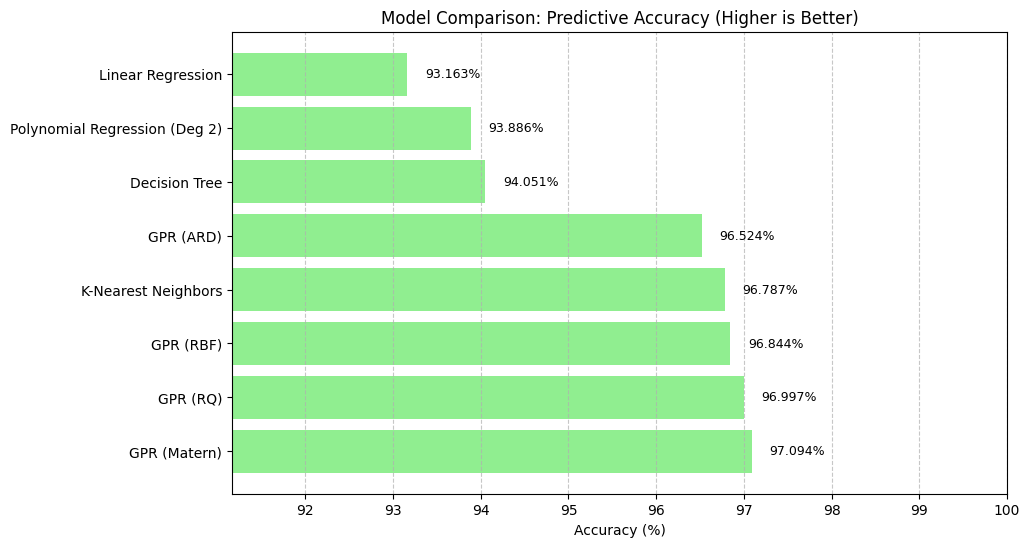

In [37]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
